In this folder, the user can find the different scripts used to apply variational autoencoders for the generation of embedding from raw gene expression datasets. 

* **The script `variational_autoencoder_nb.py`** contains the code for the generation of the embeddings. 
    -   It implements the Gaussian distribution with the reparametrization trick (used for the prior and the approximate posterior distributions). 
    -   It implements the negative binomial for the likelihood function. 

    So, we end up with a prior defined as: $$p(\mathbf{z}) := \mathcal{N}(0, I)$$

    An approximate posterior:  $$q_\phi(\mathbf{z} | \mathbf{x}) := \mathcal{N}( \mathbf{z}\ |\ \mu_\phi(\mathbf{x}) , \sigma_\phi(\mathbf{x}) I )$$

    The datasets, as in the rest of the scripts of this repository, are hosted in the folder `$BLACKHOLE/$USER`. Here, we are only considering the 'x' (that is, the raw gene expression datas, excluding the transcript datasets). The reason for this is because VAE are an unsupervised deep learning method, a generative model. Therefore, it does not need labels. 

    Note that, in contrast with other scripts from this project, the data is not log-transform, because the observation model used (a negative binomial) is used to work directly with raw counts. 

    The dataset is then divided between train, test and validation sets following the same procedure as described in other sections (with the function train_test_split, in proportions 70%, 15% and 15%, respectively).

    -   The class `VariationalAutoencoder` includes functions that define the probability distributions and the main execution flows. Particularly, the function `posterior` implements the encoder and returns the distribution $q_\phi(\mathbf{z} | \mathbf{x})$. The function `prior` implements the prior distribution of the latent space. The function `observation_model` implements the decoder and returns the negative binomial distribution $p_\phi(\mathbf{x} | \mathbf{z})$. The function `forward` computes all the necessary components for the Evidence Lower Bound (ELBO) loss function, used in the training. Finally, the aim of the function `sample_from_prior` is to generate new data samples once the VAE has been trained. 

    -   The class `VariationalInference` computes the $\beta$-ELBO. Here, we have an important hyperparameter to tune, $\beta$. It acts as a regularization weight, controlling the trade-off between the two components of the loss function (the reconstruction term and the regularization). Higher values of $\beta$ force the model to find latent representations close to the Gaussian prior. Conversely, lower values allow the posterior to deviate more from the prior. In our notebook, we have included $\beta$-annealing, with 50 warm-up epochs and a $\beta$ target of 1.0. This increases its value progressively throught the training process. 

    -   Then, the notebook continues with the training and evaluation loops. The objective here is to optimize the VAE's parameters using the $\beta$-ELBO loss, and keeping track of the performance of both the training and validation. We clip the gradients to prevent exploding gradients, a problem we have faced in the different runs. The results of the training curves is visualised with the function `make_vae_plots`. 

    -   The function `get_vae_latents` returns the latent representations for all samples. These are later saved for using them in FFNN. 

* **The script `variational_autoencoders_hyperparams.py`** has the same elementary pieces as `variational_autoencoder_nb.py`, but here we tried to search for different hyperparameter options to try to improve the performance.  

* **The script `variational_autoencoder_isoform.py`** tries to apply a semi-supervised learning approach. The loss funcion does not only include the ELBO ('unsupervised error'), but also MSE ('supervised error on Y'). The total final loss was computed as the sum of the unsupervised learning and the supervised learning, with a regularisation parameter $\lambda$ multiplying this latter. However, this strategy didn't seem to work very well and, as a result, it can be outdated with respect to the previous two. 

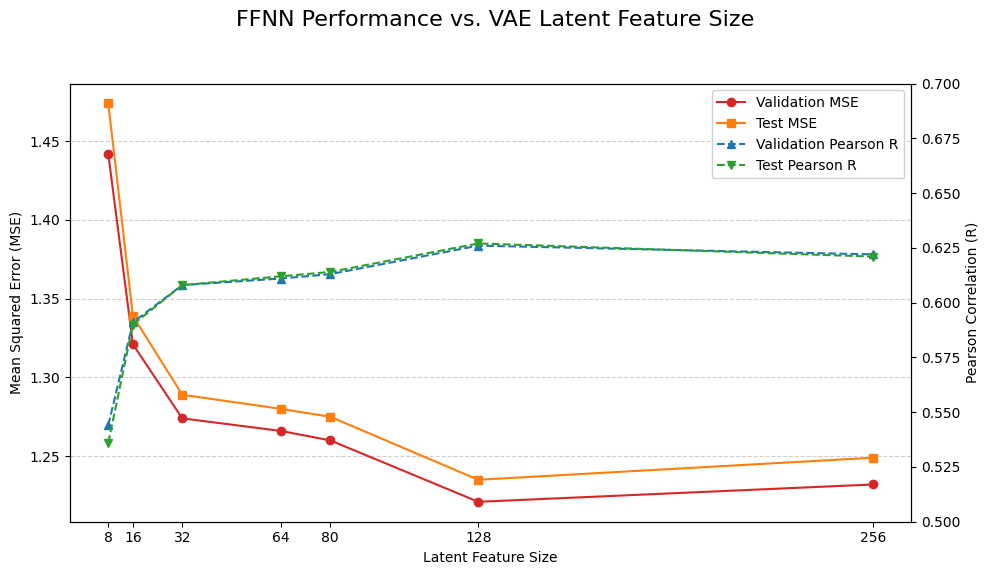

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Example Data ---
latent_sizes = [8, 16, 32, 64, 80, 128, 256]
val_mse_data = [1.442, 1.321, 1.274, 1.266, 1.260, 1.221, 1.232]
test_mse_data = [1.474, 1.339, 1.289, 1.280, 1.275, 1.235, 1.249]
val_pearson_data = [0.544, 0.591, 0.608, 0.611, 0.613, 0.626, 0.622]
test_pearson_data = [0.536, 0.590, 0.608, 0.612, 0.614, 0.627, 0.621]
# --------------------

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle('FFNN Performance vs. VAE Latent Feature Size', fontsize=16)

# --- Primary Y-axis (ax1) for MSE (Lower is better) ---
color_mse_val = 'tab:red'
color_mse_test = 'tab:orange'
ax1.set_xlabel('Latent Feature Size')
ax1.set_ylabel('Mean Squared Error (MSE)', color='black')
ax1.plot(latent_sizes, val_mse_data, label='Validation MSE', marker='o', color=color_mse_val)
ax1.plot(latent_sizes, test_mse_data, label='Test MSE', marker='s', color=color_mse_test)
ax1.tick_params(axis='y', colors='black') # Set tick color to black for clarity
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- Secondary Y-axis (ax2) for Pearson Correlation (Higher is better) ---
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_pearson_val = 'tab:blue'
color_pearson_test = 'tab:green'

# --- FIX 1: Set a neutral color for the AXIS LABEL ---
ax2.set_ylabel('Pearson Correlation (R)', color='black') 

ax2.plot(latent_sizes, val_pearson_data, label='Validation Pearson R', marker='^', color=color_pearson_val, linestyle='--')
ax2.plot(latent_sizes, test_pearson_data, label='Test Pearson R', marker='v', color=color_pearson_test, linestyle='--')

# --- FIX 2: Set a neutral color for the AXIS TICKS ---
ax2.tick_params(axis='y', colors='black')

# Ensure the Pearson R axis is focused near 1.0 (typical range 0 to 1)
# NOTE: The Pearson Correlation R is bounded between -1.0 and 1.0. 
# Since your data is positive, a range of [0.0, 1.0] is appropriate.
ax2.set_ylim([0.5, 0.7])  # Adjusted to better fit the data range

# --- Final Touches ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9) # Adjust legend position

ax1.set_xticks(latent_sizes)
# Keep log scale for x-axis as the sizes are powers of 2 for most data points
#ax1.set_xscale('log', base=2) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("FFNN_Performance_Latent_Size.png", dpi=300, bbox_inches='tight')